In [3]:
import pandas as pd
import numpy as np
import scipy.stats as st
import pingouin as pg

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
import requests
from urllib.parse import urlencode

In [3]:
base_url = 'https://cloud-api.yandex.net/v1/disk/public/resources/download?'
public_key = ['https://disk.yandex.ru/d/UhyYx41rTt3clQ', 'https://disk.yandex.ru/d/5Kxrz02m3IBUwQ',
              'https://disk.yandex.ru/d/Tbs44Bm6H_FwFQ', 'https://disk.yandex.ru/d/pH1q-VqcxXjsVA'] # ссылки на файлы



In [4]:
for num, i in enumerate(public_key):
    print(num, i)

0 https://disk.yandex.ru/d/UhyYx41rTt3clQ
1 https://disk.yandex.ru/d/5Kxrz02m3IBUwQ
2 https://disk.yandex.ru/d/Tbs44Bm6H_FwFQ
3 https://disk.yandex.ru/d/pH1q-VqcxXjsVA


In [5]:
for num, key in enumerate(public_key):
    # Получаем загрузочную ссылку
    final_url = base_url + urlencode(dict(public_key=key))
    response = requests.get(final_url)
    download_url = response.json()['href']

    # Загружаем файл и сохраняем его
    download_response = requests.get(download_url)
    if num == 0:
        with open('Проект_2_groups.csv', 'wb') as f:   
            f.write(download_response.content)
    elif num == 1:
        with open('Проект_2_group_add.csv', 'wb') as f:
            f.write(download_response.content)
    elif num == 2:
        with open('Проект_2_active_studs.csv', 'wb') as f:
            f.write(download_response.content)
    else:
        with open('Проект_2_checks.csv', 'wb') as f:
            f.write(download_response.content)
    

In [5]:
df_groups = pd.read_csv('Проект_2_groups.csv', sep=';')
df_group_add = pd.read_csv('Проект_2_group_add.csv', sep=',') # файл с пользователями спустя 2 дня после передачи данных
df_active_studs = pd.read_csv('Проект_2_active_studs.csv') # пользователи, которые зашли на платформу в дни проведения эксперимента
df_checks = pd.read_csv('Проект_2_checks.csv', sep=';')

#### Проверяю данные

In [8]:
df_groups

,id,grp
0,1489,B
1,1627,A
2,1768,B
3,1783,B
4,1794,A
...,...,...
74479,5692459,B
74480,5692572,B
74481,5692865,B
74482,5693667,B


In [9]:
df_groups.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74484 entries, 0 to 74483
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      74484 non-null  int64 
 1   grp     74484 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.1+ MB


In [10]:
df_group_add

,id,grp
0,5694584,B
1,5694830,B
2,5695057,B
3,5698872,B
4,5699067,B
...,...,...
87,200247820,B
88,201032527,B
89,201067612,B
90,201067653,B


In [11]:
df_group_add.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      92 non-null     int64 
 1   grp     92 non-null     object
dtypes: int64(1), object(1)
memory usage: 1.6+ KB


In [12]:
df_active_studs

,student_id
0,581585
1,5723133
2,3276743
3,4238589
4,4475369
...,...
8336,1794344
8337,296883
8338,3598448
8339,3610547


In [13]:
df_active_studs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8341 entries, 0 to 8340
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   student_id  8341 non-null   int64
dtypes: int64(1)
memory usage: 65.3 KB


In [14]:
df_checks

,student_id,rev
0,1627,990.0
1,3185,690.0
2,25973,690.0
3,26280,690.0
4,100300,990.0
...,...,...
536,5645737,1900.0
537,5651566,1900.0
538,5662322,1900.0
539,5681918,1900.0


In [15]:
df_checks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   student_id  541 non-null    int64  
 1   rev         541 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 8.6 KB


### Исследую данные

In [17]:
# Проверю не повторяются ли id студентов в файлах

In [18]:
df_groups.id.value_counts()

id
1489       1
2703601    1
2701748    1
2701623    1
2701496    1
          ..
1158983    1
1158968    1
1158850    1
1158847    1
5694419    1
Name: count, Length: 74484, dtype: int64

In [19]:
df_active_studs.student_id.value_counts()

student_id
581585     1
3207793    1
3311978    1
2560091    1
786697     1
          ..
481376     1
1109479    1
1095865    1
419314     1
205705     1
Name: count, Length: 8341, dtype: int64

In [20]:
df_checks.student_id.value_counts()

student_id
1627       1
3354191    1
3462630    1
3456435    1
3456377    1
          ..
1220488    1
1202202    1
1187944    1
1184303    1
5740903    1
Name: count, Length: 541, dtype: int64

In [21]:
# как мы видим нет повторений в каждом из файлов! =>
print(f'''Таким образом в день проведения эксперимента к нам зашло {df_active_studs.nunique().iloc[0]} пользователей.
А оплатило в дни проведения эксперимента {df_checks.nunique().iloc[0]} пользователь''')

Таким образом в день проведения эксперимента к нам зашло 8341 пользователей.
А оплатило в дни проведения эксперимента 541 пользователь


In [9]:
# соеденим df_groups с df_group_add чтоб иметь полный список всех пользователей
df_groups_total = pd.concat([df_groups, df_group_add], ignore_index=True)
df_groups_total.head()

,id,grp
0,1489,B
1,1627,A
2,1768,B
3,1783,B
4,1794,A


In [11]:
# Проверим не повторяются ли у нас пользователи 
df_groups_total.id.value_counts()

id
1489         1
2711518      1
2708589      1
2708295      1
2707985      1
            ..
1159611      1
1159603      1
1159557      1
1159537      1
201067659    1
Name: count, Length: 74576, dtype: int64

In [24]:
# как мы видим повторений у нас нет!

In [13]:
# соеденим df_groups_total с df_active_studs чтобы посмотреть о принадлежности пользователей к группам
df_active_studs_groups = pd.merge(df_groups_total, df_active_studs, left_on='id', right_on='student_id')
df_active_studs_groups.head()

,id,grp,student_id
0,1627,A,1627
1,2085,B,2085
2,2215,B,2215
3,3391,A,3391
4,3401,B,3401


In [15]:
# Проверим: все ли пользователи которые зашли на платформу во время эксперимента были отнесены к группам(контрольной/тестовой)
if df_active_studs_groups.nunique().iloc[0] == df_active_studs.nunique().iloc[0]:
    print(True)
else:
    print(False)

True


In [17]:
# Удалим поле 'student_id' так как он у нас повторяется с 'id'
del df_active_studs_groups['student_id']
df_active_studs_groups.head()

,id,grp
0,1627,A
1,2085,B
2,2215,B
3,3391,A
4,3401,B


In [19]:
# Аналогично соеденим df_groups_total с df_checks чтобы посмотреть о принадлежности платящих пользователей к группам
df_checks_groups = pd.merge(df_groups_total, df_checks, left_on='id', right_on='student_id')
df_checks_groups.head()

,id,grp,student_id,rev
0,1627,A,1627,990.0
1,3185,B,3185,690.0
2,25973,B,25973,690.0
3,26280,B,26280,690.0
4,100300,B,100300,990.0


In [21]:
# Проверим: все ли пользователи, которые произвели оплату были отнесены к группам(контрольной/тестовой)
if df_checks_groups.nunique().iloc[0] == df_checks.nunique().iloc[0]:
    print(True)
else:
    print(False)

True


In [23]:
# Удалим поле 'student_id' так как он у нас повторяется с 'id'
del df_checks_groups['student_id']
df_checks_groups.head()

,id,grp,rev
0,1627,A,990.0
1,3185,B,690.0
2,25973,B,690.0
3,26280,B,690.0
4,100300,B,990.0


### На какие метрики вы смотрите в ходе анализа и почему?
Сначала я потсмрю кол-во людей(пользователей), которые находятся в тестовой и в контрольной группе(пользователи, которые зашли на платформу в дни проведения эксперимента; пользователи, которые оплатили в дни проведения эксперимента) их примерно должно быть поровну. 
Минус данного эксперимента в том, что мы не можем разделить пользователей на когорты/сегменты(например по возрасту, полу, демографии и т.п.).
И из-за этого в контрольную и в тестовую группу могли попасть разные люди(т.е. например в контрольной группе могли находиться люди более старшего возраста, а в тестовой - молодежь). 
1. Первую метрику будут смотреть: конверсию в платящего пользователя в тестовой и контрольной группе. Она нам важна, что бы понять усложнит или облегчит новая механика оплаты услуг на сайте. Может случится так, что новая механика оплаты услуг на сайте  будет более сложной или, например, если ее полностью поменяют и пользователи, которые давно находятся и оплачивают услуги с данной сайта -> могут начать путаться в новом дизайне или новой механике оплаты. И следовательно из-за этого давние пользователи могут начать уходить от нас -> конверсия в платящего пользователя может упасть.
2. Вторую метрику можно посмотреть: средний доход на одного платящего пользователя (ARPPU) или средний доход на одного пользователя(ARPU). Я считаю, что лучше всего посчитать ARPU так как например, у нас может значительно увеличится конверсия в платящего пользователя, в то время как выручка может вырасти незначительно. ARPU = (выручка / кол-во уникальных пользователей в каждой из групп). Мы увидим, что ARPU может чуть вырости (при условии, что кол-во пользователей в каждой из групп одинаковое). В это время ARPPU = (выручка / кол-во уникальных пользователей совершивших платеж). Мы увидим, что ARPPU может сильно упасть, так как конверсия в платящего пользователя сильно выросла, а выручка выросла незначительно => очевидно, что она упадет, но как сильно упадет - это уже другой вопрос.
Приведу пример: A: суммарная выручка = 5000, кол-во пользователей = 200, платящих пользователей = 100.
конверсия = 50% ARPPU = 5000/100 = 50 ARPU = 5000/200 = 25
Б: суммарная выручка = 6000, кол-во пользователей = 200, платящих пользователей = 150. 
конверсия = 75% ARPPU = 6000/150 = 40 ARPU = 6000/200 = 30
Как мы видим, мы значительно подняли конверсию. Но новые пользователи не конпенсировали большой рост конверсии своей выручкой => ARPPU ⬇️ а ARPU ⬆️ но не так сильно. И таким образом может сложиться двоякое впечатление, что конверсия выросла, причем очень хорошо, но ARPPU упало (на 20% см.пример). Но с другой стороны ARPU может вырости не значительно. И получается, что мы провели A/B по метрике "конверсия в платящего пользователя" и увидели стат. значимый результат ("положительный"), а с другой стороны ARPPU падает на 20% - и проводя по данной метрике стат. тест, мы можем обратную картину, а может и показать, что нет стат. значимых различий! Но это сильно зависит от того, какую ключевую метрику мы выбедем для данного бизнес-кейса!

:) Так вот, все я это к чему говорю, вторую метрику я буду смотреть ARPU и ARPPU - как по мне из-за всего выше изложенного - она будет более уместна. 

Итак я выбрал две целевые метрика: 1. Конверсия в платящего пользователя; 2. ARPPU; 3. ARPU

In [33]:
# Посмотрим на наши данные и определим конверсию в платящего пользователя и ARPU

In [25]:
# объеденим таблицы активных пользователей и пользователей, которые зашли в дни проведения эксперимента
df_active_checks_studs = pd.merge(df_active_studs_groups, df_checks_groups, on=['id'], how='outer')
df_active_checks_studs

,id,grp_x,grp_y,rev
0,1627,A,A,990.0
1,2085,B,NaN,NaN
2,2215,B,NaN,NaN
3,3185,NaN,B,690.0
4,3391,A,NaN,NaN
...,...,...,...,...
8485,5760471,B,NaN,NaN
8486,5777081,B,NaN,NaN
8487,5870856,A,NaN,NaN
8488,5945085,B,NaN,NaN


In [27]:
# теперь для всех пользователей определим группы к которым они относятся 
df_active_checks_studs_groups = pd.merge(df_active_checks_studs, df_groups_total, on='id')
df_active_checks_studs_groups

,id,grp_x,grp_y,rev,grp
0,1627,A,A,990.0,A
1,2085,B,NaN,NaN,B
2,2215,B,NaN,NaN,B
3,3185,NaN,B,690.0,B
4,3391,A,NaN,NaN,A
...,...,...,...,...,...
8485,5760471,B,NaN,NaN,B
8486,5777081,B,NaN,NaN,B
8487,5870856,A,NaN,NaN,A
8488,5945085,B,NaN,NaN,B


In [29]:
del df_active_checks_studs_groups['grp_x']
del df_active_checks_studs_groups['grp_y']

In [31]:
df_active_checks_studs_groups.head()

,id,rev,grp
0,1627,990.0,A
1,2085,NaN,B
2,2215,NaN,B
3,3185,690.0,B
4,3391,NaN,A


In [33]:
# Посчитаем кол-во пользователей и выручку в каждой из групп
df_target_metrics = df_active_checks_studs_groups.groupby('grp', as_index=False).agg({'id': 'count',
                                                                                      'rev': 'sum'}) \
                                                                                .rename(columns={'id': 'count_active_user',
                                                                                                 'rev': 'sum_rev'})
df_target_metrics

,grp,count_active_user,sum_rev
0,A,1567,92096.0000
1,B,6923,481230.0036


In [35]:
# посчитаем кол-во платящих пользователей
df_active_checks_studs_groups['rev'] = df_active_checks_studs_groups['rev'].fillna(0) # заменяем пустые значения на 0
df_target_metrics['count_check_user'] = df_active_checks_studs_groups.query('rev != 0').groupby('grp', as_index=False)['id'].count()['id']
df_target_metrics

,grp,count_active_user,sum_rev,count_check_user
0,A,1567,92096.0000,107
1,B,6923,481230.0036,434


In [37]:
# посчитаем конверсию в платящего пользователя
df_target_metrics['conversion_rate'] =  round(df_target_metrics['count_check_user'] / 
                                              df_target_metrics['count_active_user'] 
                                              * 100, 
                                              2)

In [39]:
df_target_metrics

,grp,count_active_user,sum_rev,count_check_user,conversion_rate
0,A,1567,92096.0000,107,6.83
1,B,6923,481230.0036,434,6.27


In [41]:
df_target_metrics['ARPPU'] = round(df_target_metrics['sum_rev'] / df_target_metrics['count_check_user'], 1)
df_target_metrics['ARPU'] = round(df_target_metrics['sum_rev'] / df_target_metrics['count_active_user'], 1)

In [43]:
df_target_metrics

,grp,count_active_user,sum_rev,count_check_user,conversion_rate,ARPPU,ARPU
0,A,1567,92096.0000,107,6.83,860.7,58.8
1,B,6923,481230.0036,434,6.27,1108.8,69.5


In [312]:
print(f'''Конверсия в группе A не значительно больше, чем в группе B на {round(6.83 - 6.27, 2)}. При этом кол-во активных пользователей в тестовой 
группе в {round(6923/1567, 1)} больше чем в контрольной, а кол-во платящих пользователей в {round(434/107, 1)} больше чем в контрольной.
Но при этом ARPPU в контрольной группе меньше, чем в тестововй на {round(1108.8 - 860.7, 1)} у.е. и аналогично с ARPU: {round(69.5 - 58.8, 1)} у.е.
Так же рост выручки у нас составил в {round(481230.0036/92096, 1)}''')

Конверсия в группе A не значительно больше, чем в группе B на 0.56. При этом кол-во активных пользователей в тестовой 
группе в 4.4 больше чем в контрольной, а кол-во платящих пользователей в 4.1 больше чем в контрольной.
Но при этом ARPPU в контрольной группе меньше, чем в тестововй на 248.1 у.е. и аналогично с ARPU: 10.7 у.е.
Так же рост выручки у нас составил в 5.2


Итак, кол-во людей, которые зашли на платформу в группе А значительно меньше, чем в группе B (чуть больше чем в 4 раза).
Аналогичная ситуация наблюдается и с кол-во людей, которые совершили платеж на данном сайте (в группе А совершили платеж примерно в 4 раза меньше людей, чем в группе B). Помимо этого мы видим, что конверсию в группе A > B на 0.56%, т.е. конверсия у нас упала в результате введения новой механики оплаты (это скорее всего из-за того, что кол-во людей, которые зашли на платформу в тестовой группе значительно больше, чем в контрльной (в 4.4 раза), и аналогично кол-во клиентов которые сделали платеж в тестовой группе значительно больше чем в контрольной (в 4.1 раза) -> т.е. небольшое отличие есть ). Но при этом ARPU и ARPPU выросли (это из-за того, что выручка выросла больше (в 5.2), чем увеличилось кол-во активных (и платящих) пользователей (в 4.4 и 4.1 соотв.))

Итак, мы должны выбрать одну ключевую метрику для проведения A/B теста. Данная матрика должна обладать след. свойствами:
1) Чувствительность;
2) Достоверность;
3) Интерпретируемость

Так как мы предлагаем новую механику оплаты услуг на сайте, то наша цель повысить общий доход на пользователя (а не только тех пользователей, которые нам уже платят деньги) => Ключевая метрика будет ARPU.


In [326]:
# Посмотрим характер распределения наших данных в каждой из групп
# не берем нулевые значения, чтобы понять распределение не нулевых данных(т.к. нулевые значения могут исказить распределение данных) 
group_A = df_active_checks_studs_groups.query("grp == 'A' and rev != 0")
group_B = df_active_checks_studs_groups.query("grp == 'B' and rev != 0")

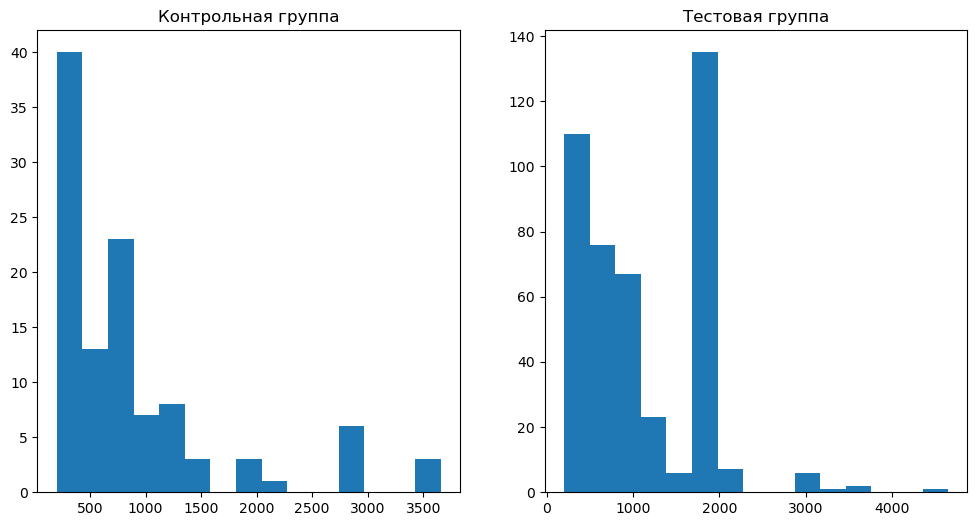

In [382]:
plt.figure(figsize=[12, 6])
ax1 = plt.subplot(121)
ax1.hist(group_A['rev'], bins=15)
ax1.set_title('Контрольная группа')

ax2 = plt.subplot(122)
ax2.hist(group_B['rev'], bins=15)
ax2.set_title('Тестовая группа')

plt.show()

Как вы видим, данные об оплатах пользователей имеют не нормалное распределение. Но для более точного убеждения проведу тест Шапиро-Уилка на нормальность:

H0: наши данные имеют нормальное распределение

H1: наши данные имеют не нормальное распределение

Вероястность ошибки 1-ого рода задам по стандарту alpha = 0.05 


In [397]:
print(f'Для контрольной группы {st.shapiro(group_A['rev'])}')
print(f'Для тестовой группы {st.shapiro(group_B['rev'])}')

Для контрольной группы ShapiroResult(statistic=0.7196124408128413, pvalue=5.321662581039505e-13)
Для тестовой группы ShapiroResult(statistic=0.8672362401403875, pvalue=8.94770606307257e-19)


Итак, мы отвергаем нулевую гипотезы о нормальности распределений в контрольной и тестовой группе! 

=> буду использовать непараметрический тест.

### Проведение A/B теста
Итак, сформулирую следующие стат. гипотезы: 

H0: Средний доход на одного пользователя в тестовой и контрольной группах одинаковое

H1: Средний доход на одного пользователя в тестовой и контрольной группах разное

Ошибку первого рода alpha = 0.05, beta = 0.2, Стат мощность N = 0.8 

In [402]:
df_target_metrics[['grp', 'count_active_user', 'ARPU']]

,grp,count_active_user,ARPU
0,A,1567,58.8
1,B,6923,69.5


In [404]:
# контрольная группа
n_A = df_target_metrics['count_active_user'].iloc[0]
ARPU_A = df_target_metrics['ARPU'].iloc[0]
print(f'размер выборки контрольной группы {n_A}, и ср. доход на одного пользователя {ARPU_A}')

# тестовая группа
n_B = df_target_metrics['count_active_user'].iloc[1]
ARPU_B = df_target_metrics['ARPU'].iloc[1]
print(f'размер выборки тестовой группы {n_B}, и ср. доход на одного пользователя {ARPU_B}')

размер выборки контрольной группы 1567, и ср. доход на одного пользователя 58.8
размер выборки тестовой группы 6923, и ср. доход на одного пользователя 69.5


In [432]:
# рассчитаю дисперсию и стандартное отклонение
var_A = round(np.var(a=list(df_active_checks_studs_groups.query("grp == 'A'")['rev'])), 2)
std_A = round(np.std(a=list(df_active_checks_studs_groups.query("grp == 'A'")['rev'])), 2)
print(f'Дисперсия контрольной группы = {var_A}, а стандартное отклонение = {std_A}')

var_B = round(np.var(a=list(df_active_checks_studs_groups.query("grp == 'B'")['rev'])), 2)
std_B = round(np.std(a=list(df_active_checks_studs_groups.query("grp == 'B'")['rev'])), 2)
print(f'Дисперсия тестовой группы = {var_B}, а стандартное отклонение = {std_B}')

Дисперсия контрольной группы = 92161.84, а стандартное отклонение = 303.58
Дисперсия тестовой группы = 106664.22, а стандартное отклонение = 326.59


In [436]:
# Оценим эффект между контрольной и тестовой группой
mean_A = ARPU_A
mean_B = ARPU_B
diff = round(mean_B - mean_A, 1)
print(f'''Среднее значение контрольной группы {mean_A} с размером выборки {n_A}. 
Среднее значение тестовой группы {mean_B} с размером выборки {n_B}
Разность тестовой и контрольной группы {diff}''')

Среднее значение контрольной группы 58.8 с размером выборки 1567. 
Среднее значение тестовой группы 69.5 с размером выборки 6923
Разность тестовой и контрольной группы 10.7


##### Итак, так как у нас дисперсии в контрольной и тестовой группах не одинаковые, а также распределение данных в контрольной и тестовой группах имеют ненормальное распределение -> использую непараметрический тест Welch t-test

In [456]:
# Рассчитаем T-статистику t = (mean_test - mean_control) / sqrt( var_control/n_control + var_test/n_test )
t = round(diff / np.sqrt(var_A/n_A + var_B/n_B), 3)
print(f'Т-статистика = {t}')

Т-статистика = 1.242


In [478]:
# Рассчитаем число степеней свободы по Уэлчу
df = round((var_A/n_A + var_B/n_B)**2 / ((var_A/n_A)**2 / (n_A-1) + (var_B/n_B)**2 / (n_B-1)))
print(f'Число степеней свободы = {df}')

Число степеней свободы = 2456


In [518]:
# Рассчитаем p-значение
p_value = st.t.cdf(-t, df=df)
print(f'''Так как изначально было сказано в альтернативной гипотезе \'Средний доход на одного пользователя в тестовой и контрольной группах разное\',
то то у нас двухсторонний тест => p={round(2 * p_value, 2)}''')

Так как изначально было сказано в альтернативной гипотезе 'Средний доход на одного пользователя в тестовой и контрольной группах разное',
то то у нас двухсторонний тест => p=0.21


#### Итак, вероятсноть получить такие же или больше по модулю различия, если верна нулевая гипотеза = 0.21 > 0.05 т.е. различия не являются статистически значимыми => нулевую гипотезу мы отвергнуть не можем при данном уровне значимости!
Таким образом, не стоит запускать новую механику оплаты услуг на сайте. 

### Проведение метода bootstrap

In [45]:
df_target_metrics

,grp,count_active_user,sum_rev,count_check_user,conversion_rate,ARPPU,ARPU
0,A,1567,92096.0000,107,6.83,860.7,58.8
1,B,6923,481230.0036,434,6.27,1108.8,69.5


In [47]:
df_active_checks_studs_groups

,id,rev,grp
0,1627,990.0,A
1,2085,0.0,B
2,2215,0.0,B
3,3185,690.0,B
4,3391,0.0,A
...,...,...,...
8485,5760471,0.0,B
8486,5777081,0.0,B
8487,5870856,0.0,A
8488,5945085,0.0,B


In [61]:
check_users_grp_A = df_active_checks_studs_groups.query("rev != 0 & grp == 'A'")
check_users_grp_B = df_active_checks_studs_groups.query("rev != 0 & grp == 'B'")

In [83]:
check_users_grp_A['rev'].sample(frac=1, replace=True)

7153     290.0
1352     290.0
5326     290.0
7934     290.0
8125     290.0
         ...  
3899    1140.0
1109    2900.0
1288    1980.0
1640    1980.0
1693     990.0
Name: rev, Length: 107, dtype: float64

In [92]:
medians_grp_A = []
mean_grp_A = []

for i in range(10_000):
    sample_data = check_users_grp_A['rev'].sample(frac=1, replace=True)
    
    sample_medians = sample_data.median()
    medians_grp_A.append(sample_medians)
    
    sample_mean = sample_data.mean()
    mean_grp_A.append(sample_mean)



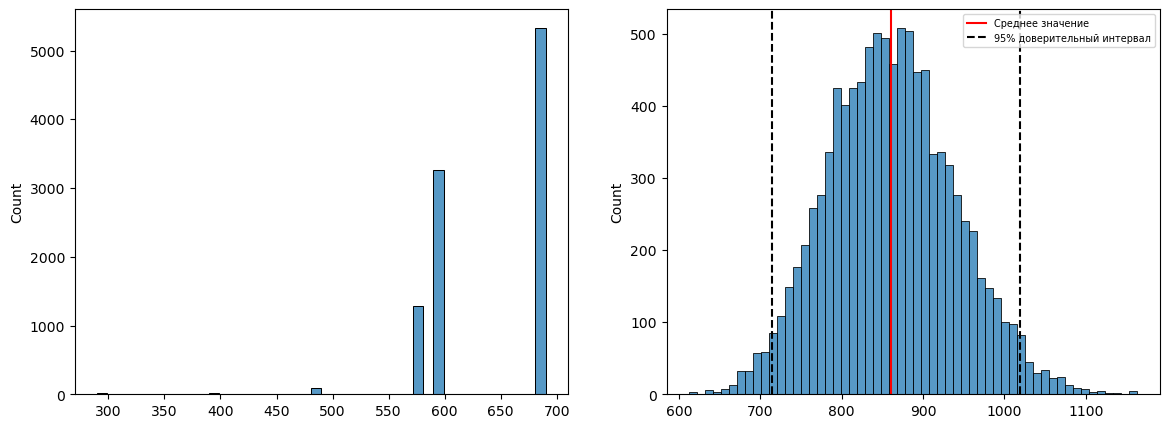

In [196]:
fig = plt.figure(figsize=(14, 5))

ax1 = fig.add_subplot(121)
sns.histplot(data=medians_grp_A)

ax2 = fig.add_subplot(122)
sns.histplot(data=mean_grp_A)
ax2.axvline(np.mean(mean_grp_A), color='r', label='Среднее значение')
ax2.axvline(np.quantile(mean_grp_A, 0.025), color='black', linestyle='--', label='95% доверительный интервал')
ax2.axvline(np.quantile(mean_grp_A, 0.975), color='black', linestyle='--')

plt.legend(fontsize=7)
plt.show()

In [203]:
# Проделаю все тоже самое с тестовой группой!
medians_grp_B = []
mean_grp_B = []

for i in range(10_000):
    sample_data = check_users_grp_B['rev'].sample(frac=1, replace=True)
    
    sample_medians = sample_data.median()
    medians_grp_B.append(sample_medians)
    
    sample_mean = sample_data.mean()
    mean_grp_B.append(sample_mean)



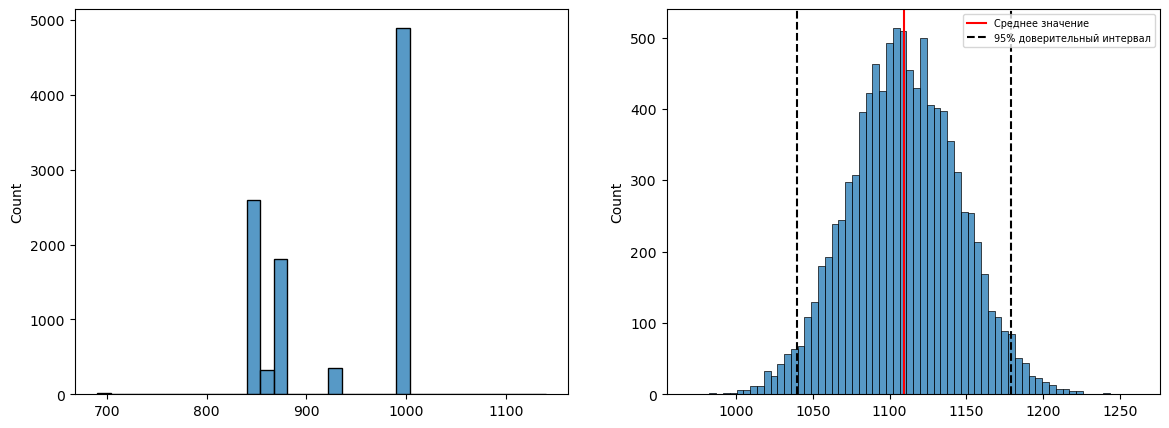

In [205]:
fig = plt.figure(figsize=(14, 5))

ax1 = fig.add_subplot(121)
sns.histplot(data=medians_grp_B)

ax2 = fig.add_subplot(122)
sns.histplot(data=mean_grp_B)
ax2.axvline(np.mean(mean_grp_B), color='r', label='Среднее значение')
ax2.axvline(np.quantile(mean_grp_B, 0.025), color='black', linestyle='--', label='95% доверительный интервал')
ax2.axvline(np.quantile(mean_grp_B, 0.975), color='black', linestyle='--')

plt.legend(fontsize=7)
plt.show()

In [291]:
dict_A_B = dict({'A': mean_grp_A,
                 'B': mean_grp_B})

In [347]:
data_frame_A = pd.DataFrame(columns=('grp', 'values'))
data_frame_B = pd.DataFrame(columns=('grp', 'values'))

In [349]:
data_frame_A['values'] = dict_A_B['A']
data_frame_A['grp'] = list(dict_A_B.keys())[0]
data_frame_B['values'] = dict_A_B['B']
data_frame_B['grp'] = list(dict_A_B.keys())[1]

In [371]:
data_frame_A_B = pd.concat([data_frame_A, data_frame_B], ignore_index=True)

In [377]:
data_frame_A_B

,grp,values
0,A,893.345794
1,A,786.158879
2,A,845.280374
3,A,846.785047
4,A,935.411215
...,...,...
19995,B,1141.649778
19996,B,1118.253466
19997,B,1041.018440
19998,B,1099.161299


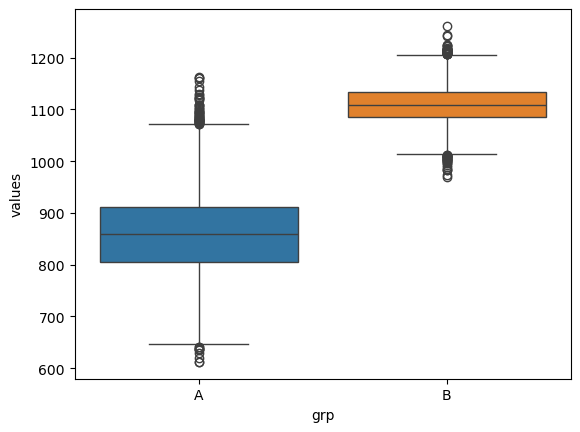

In [395]:
sns.boxplot(data=data_frame_A_B, x='grp', y='values', hue='grp')

plt.show()